# ALPA-Net Transfer Fine-Tuning CV

5-fold cross validation on PTB Diagnostic for four transfer learning strategies.

## 1. Imports and CONFIG

In [1]:
import json
import logging
import random
import re
import time
import traceback
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    accuracy_score,
)
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset, Subset

sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path('.').resolve()
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

CONFIG = {
    'SEED': 42,
    'FAST_DEV_RUN': False,
    'RESUME': False,
    'PRETRAIN_ROOT': str(PROJECT_ROOT / 'outputs' / 'pretrain_alpanet_ptbxl'),
    'PRETRAIN_RUN_ID': 'latest',
    'DATASET_DIR': str(PROJECT_ROOT / 'dataset' / 'ptb_diagnostic'),
    'OUTPUT_BASE_DIR': str(PROJECT_ROOT / 'outputs' / 'finetune_alpanet_ptbdiagnostic'),
    'RUN_ID': RUN_TIMESTAMP,
    'N_FOLDS': 5,
    'STRATEGIES': ['no_pretrain', 'frozen_backbone', 'partial_finetune', 'full_finetune'],
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'BATCH_SIZE': 32,
    'EPOCHS': 50,
    'LR': 5e-4,
    'HEAD_LR_MULTIPLIER': 2.0,
    'WEIGHT_DECAY': 1e-4,
    'NUM_WORKERS': 2,
    'THRESHOLD': 0.5,
    'USE_THRESHOLD_TUNING': True,
    'EARLY_STOPPING_ENABLED': True,
    'EARLY_STOPPING_PATIENCE': 12,
    'SCHEDULER_PATIENCE': 5,
    'lambda_alpa': 0.2,
    'lambda_territory': 0.3,
    'lambda_exclusive': 0.1,
    'lambda_consistency': 0.1,
    'MODEL': {
        'input_leads': 12,
        'signal_length': 1000,
        'stem_channels': 32,
        'cnn_channels': 64,
        'token_dim': 128,
        'num_heads': 4,
        'cross_lead_layers': 2,
        'temporal_layers': 1,
        'transformer_ff_dim': 256,
        'dropout': 0.20,
        'temporal_segments': 20,
        'main_outputs': 4,
        'territory_outputs': 3,
    },
}
if CONFIG['FAST_DEV_RUN']:
    CONFIG['N_FOLDS'] = 1
    CONFIG['STRATEGIES'] = ['frozen_backbone']
    CONFIG['EPOCHS'] = 2
    CONFIG['NUM_WORKERS'] = 0

MAIN_LABELS = ['Normal', 'Anterior', 'Inferior', 'Lateral']
TERRITORY_LABELS = ['Anterior', 'Inferior', 'Lateral']
LEAD_ORDER = ['I', 'aVL', 'II', 'III', 'aVF', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LABEL_MAPPING = {'main_label_order': MAIN_LABELS, 'territory_order': TERRITORY_LABELS, 'multi_label': True}
LEAD_PRIOR_CONFIG = {
    'lead_order': LEAD_ORDER,
    'normal': 'uniform over 12 leads',
    'territories': {'Anterior': ['V1', 'V2', 'V3', 'V4'], 'Inferior': ['II', 'III', 'aVF'], 'Lateral': ['I', 'aVL', 'V5', 'V6']},
}
print('Device:', CONFIG['DEVICE'])

Device: cuda


## 2. Output directory setup

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['SEED'])
OUTPUT_DIR = Path(CONFIG['OUTPUT_BASE_DIR']) / CONFIG['RUN_ID']
CONFIG_DIR = OUTPUT_DIR / 'configs'
LOG_DIR = OUTPUT_DIR / 'logs'
FOLDS_DIR = OUTPUT_DIR / 'folds'
AGG_DIR = OUTPUT_DIR / 'aggregate_results'
PLOTS_DIR = OUTPUT_DIR / 'plots'
for d in [CONFIG_DIR, LOG_DIR, FOLDS_DIR, AGG_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
with open(CONFIG_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
with open(CONFIG_DIR / 'label_mapping.json', 'w') as f:
    json.dump(LABEL_MAPPING, f, indent=2)
print('Output:', OUTPUT_DIR)

Output: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/finetune_alpanet_ptbdiagnostic/20260607_200953


## 3. Logging setup

In [3]:
def make_logger(name, train_log_path, error_log_path, also_root=False):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    fmt = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    fh = logging.FileHandler(train_log_path)
    fh.setFormatter(fmt)
    eh = logging.FileHandler(error_log_path)
    eh.setLevel(logging.ERROR)
    eh.setFormatter(fmt)
    logger.addHandler(sh)
    logger.addHandler(fh)
    logger.addHandler(eh)
    if also_root:
        root_fh = logging.FileHandler(PROJECT_ROOT / 'finetune_output.log')
        root_fh.setFormatter(fmt)
        logger.addHandler(root_fh)
    return logger

global_logger = make_logger('finetune_alpanet_global', LOG_DIR / 'train.log', LOG_DIR / 'error.log', also_root=True)
global_logger.info('Output directory: %s', OUTPUT_DIR)
global_logger.info('Root live log: %s', PROJECT_ROOT / 'finetune_output.log')

2026-06-07 20:09:54,055 | INFO | Output directory: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/finetune_alpanet_ptbdiagnostic/20260607_200953


2026-06-07 20:09:54,056 | INFO | Root live log: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/finetune_output.log


## 4. Load pretrain source

In [4]:
def load_pretrain_run(pretrain_root, run_id='latest'):
    root = Path(pretrain_root)
    if not root.exists():
        raise FileNotFoundError(f'PRETRAIN_ROOT not found: {root}')
    if run_id == 'latest':
        candidates = sorted([p for p in root.iterdir() if p.is_dir()])
        if not candidates:
            raise FileNotFoundError(f'No pretrain run folders found under {root}')
        run_dir = candidates[-1]
    else:
        run_dir = root / run_id
    transfer_dir = run_dir / 'transfer_ready'
    ckpt_dir = run_dir / 'checkpoints'
    transfer_dir.mkdir(parents=True, exist_ok=True)

    config_path = run_dir / 'configs' / 'config.json'
    ckpt_candidates = [ckpt_dir / 'best_macro_f1.pt', ckpt_dir / 'best_val_loss.pt', ckpt_dir / 'last.pt']
    ckpt_path = next((path for path in ckpt_candidates if path.exists()), None)
    if ckpt_path is None:
        raise FileNotFoundError(f'No checkpoint found in {ckpt_dir}. Expected best_macro_f1.pt, best_val_loss.pt, or last.pt')

    required = {
        'backbone': transfer_dir / 'alpanet_backbone.pt',
        'full_model': transfer_dir / 'alpanet_full_model.pt',
        'model_config': transfer_dir / 'model_config.json',
        'label_mapping': transfer_dir / 'label_mapping.json',
        'lead_prior_config': transfer_dir / 'lead_prior_config.json',
    }
    missing = [key for key, path in required.items() if not path.exists()]
    if missing:
        payload = torch.load(ckpt_path, map_location='cpu')
        if 'backbone_state_dict' not in payload or 'model_state_dict' not in payload:
            raise FileNotFoundError('Transfer-ready files missing and checkpoint does not contain required state dicts: ' + ', '.join(missing))
        torch.save({'backbone_state_dict': payload['backbone_state_dict'], 'config': payload.get('config', {}), 'label_mapping': payload.get('label_mapping', LABEL_MAPPING), 'lead_prior_config': payload.get('lead_prior_config', LEAD_PRIOR_CONFIG)}, required['backbone'])
        torch.save({'model_state_dict': payload['model_state_dict'], 'backbone_state_dict': payload['backbone_state_dict'], 'config': payload.get('config', {}), 'label_mapping': payload.get('label_mapping', LABEL_MAPPING), 'lead_prior_config': payload.get('lead_prior_config', LEAD_PRIOR_CONFIG)}, required['full_model'])
        cfg = payload.get('config', {})
        model_cfg = cfg.get('model', cfg.get('MODEL', CONFIG['MODEL']))
        with open(required['model_config'], 'w') as f:
            json.dump(model_cfg, f, indent=2)
        with open(required['label_mapping'], 'w') as f:
            json.dump(payload.get('label_mapping', LABEL_MAPPING), f, indent=2)
        with open(required['lead_prior_config'], 'w') as f:
            json.dump(payload.get('lead_prior_config', LEAD_PRIOR_CONFIG), f, indent=2)

    final_missing = [str(path) for path in required.values() if not path.exists()]
    if final_missing:
        raise FileNotFoundError('Missing pretrained files:\n' + '\n'.join(final_missing))
    source = {'run_dir': str(run_dir), 'transfer_dir': str(transfer_dir), 'checkpoint_source': str(ckpt_path), **{k: str(v) for k, v in required.items()}}
    with open(CONFIG_DIR / 'pretrain_source.json', 'w') as f:
        json.dump(source, f, indent=2)
    return source

try:
    PRETRAIN_SOURCE = load_pretrain_run(CONFIG['PRETRAIN_ROOT'], CONFIG['PRETRAIN_RUN_ID'])
    global_logger.info('Using pretrained run: %s', PRETRAIN_SOURCE['run_dir'])
except Exception as exc:
    global_logger.error('Failed to load pretrain source: %s\n%s', exc, traceback.format_exc())
    raise

def load_json(path):
    with open(path) as f:
        return json.load(f)

pretrain_model_config = load_json(PRETRAIN_SOURCE['model_config'])
pretrain_label_mapping = load_json(PRETRAIN_SOURCE['label_mapping'])
pretrain_lead_prior_config = load_json(PRETRAIN_SOURCE['lead_prior_config'])
CONFIG['MODEL'].update(pretrain_model_config)
if pretrain_label_mapping.get('main_label_order', MAIN_LABELS) != MAIN_LABELS:
    raise ValueError(f'Pretrain label mapping incompatible: {pretrain_label_mapping}')
if pretrain_lead_prior_config.get('lead_order', LEAD_ORDER) != LEAD_ORDER:
    raise ValueError(f'Pretrain lead order incompatible: {pretrain_lead_prior_config}')
global_logger.info('Pretrain source sanity checks passed.')

2026-06-07 20:09:54,062 | INFO | Using pretrained run: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207


2026-06-07 20:09:54,063 | INFO | Pretrain source sanity checks passed.


## 5. Data loading and label mapping

In [5]:
def normalize_label_text(value):
    if value is None or pd.isna(value):
        return ''
    text = str(value).strip().lower().replace('_', '-').replace('/', '-').replace(',', ' ')
    text = re.sub(r'\([^)]*\)', ' ', text)
    text = re.sub(r'[^a-z0-9\- ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    aliases = {'anteroseptal': 'antero-septal', 'anterolateral': 'antero-lateral', 'inferolateral': 'infero-lateral', 'inferoposterior': 'infero-posterior', 'inferoposterolateral': 'infero-postero-lateral', 'posterolateral': 'postero-lateral'}
    for src, dst in aliases.items():
        text = text.replace(src, dst)
    return text

def build_territory_vector(label_text):
    texts = label_text if isinstance(label_text, (list, tuple, set)) else [label_text]
    territories = set()
    for value in texts:
        text = normalize_label_text(value)
        if not text or text in {'normal', 'no', 'unknown', 'nan'}:
            continue
        if 'antero-lateral' in text:
            territories.update(['Anterior', 'Lateral'])
        elif 'anterior' in text or 'antero' in text:
            territories.add('Anterior')
        if 'infero-postero-lateral' in text or 'infero-poster-lateral' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'infero-lateral' in text or 'infero-latera' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'inferior' in text or 'infero' in text:
            territories.add('Inferior')
        if 'postero-lateral' in text or 'lateral' in text:
            territories.add('Lateral')
    return np.array([1 if label in territories else 0 for label in TERRITORY_LABELS], dtype=np.float32)

def build_lead_prior_vector(territory_vector):
    territory_vector = np.asarray(territory_vector, dtype=np.float32)
    active = [name for name, flag in zip(TERRITORY_LABELS, territory_vector) if flag > 0]
    if not active:
        return np.ones(len(LEAD_ORDER), dtype=np.float32) / len(LEAD_ORDER)
    weights = np.zeros(len(LEAD_ORDER), dtype=np.float32)
    active_leads = set()
    for territory in active:
        active_leads.update(LEAD_PRIOR_CONFIG['territories'][territory])
    for lead in active_leads:
        weights[LEAD_ORDER.index(lead)] = 1.0
    return weights / weights.sum()

def build_main_label_vector(sub_label):
    territory = build_territory_vector(sub_label)
    if normalize_label_text(sub_label) == 'normal' and territory.sum() == 0:
        return np.array([1, 0, 0, 0], dtype=np.float32)
    return np.concatenate([[0], territory]).astype(np.float32)

def validate_label_mapping(y_main, y_territory, lead_prior, labels_df, name):
    assert y_main.shape[1] == 4, f'{name}: main label length != 4'
    assert y_territory.shape[1] == 3, f'{name}: territory length != 3'
    assert lead_prior.shape[1] == 12, f'{name}: lead prior length != 12'
    if not np.allclose(lead_prior.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f'{name}: lead_prior rows must sum to 1')
    if ((y_main[:, 0] == 1) & (y_main[:, 1:].sum(axis=1) > 0)).any():
        raise ValueError(f'{name}: Normal active together with MI territory')
    display(pd.Series(y_main.sum(axis=0).astype(int), index=MAIN_LABELS, name=name).to_frame())
    print(f'{name} multi-territory samples:', int((y_territory.sum(axis=1) > 1).sum()))
    display(labels_df.head(10))

DATASET_DIR = Path(CONFIG['DATASET_DIR'])
x_all = np.load(DATASET_DIR / 'x_all.npy').astype(np.float32)
y_main_all = np.load(DATASET_DIR / 'main_label_all.npy').astype(np.float32)
y_territory_all = np.load(DATASET_DIR / 'territory_all.npy').astype(np.float32)
lead_prior_all = np.load(DATASET_DIR / 'lead_prior_all.npy').astype(np.float32)
labels_all = pd.read_csv(DATASET_DIR / 'labels_all.csv')
metadata_all = pd.read_csv(DATASET_DIR / 'metadata_all.csv')
validate_label_mapping(y_main_all, y_territory_all, lead_prior_all, labels_all, 'PTB Diagnostic')

,PTB Diagnostic
Normal,80
Anterior,190
Inferior,192
Lateral,139


PTB Diagnostic multi-territory samples: 152


,record_id,dataset_source,source_index,patient_id,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector,signal_path,fold,is_multi_territory
0,s0010_re,ptb_diagnostic,0,patient001,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",patient001/s0010_re,NaN,1
1,s0014lre,ptb_diagnostic,1,patient001,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",patient001/s0014lre,NaN,1
2,s0016lre,ptb_diagnostic,2,patient001,Myocardial infarction|infero-latera|no,infero-latera,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",patient001/s0016lre,NaN,1
3,s0015lre,ptb_diagnostic,3,patient002,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient002/s0015lre,NaN,0
4,s0017lre,ptb_diagnostic,4,patient003,Myocardial infarction|infero-postero-lateral|no,infero-postero-lateral,"[0, 0, 1, 1]","[0, 1, 1]","[0.14285715, 0.14285715, 0.14285715, 0.1428571...",patient003/s0017lre,NaN,1
5,s0020are,ptb_diagnostic,5,patient004,Myocardial infarction|antero-septal|no,antero-septal,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient004/s0020are,NaN,0
6,s0020bre,ptb_diagnostic,6,patient004,Myocardial infarction|antero-septal|no,antero-septal,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient004/s0020bre,NaN,0
7,s0021are,ptb_diagnostic,7,patient005,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient005/s0021are,NaN,0
8,s0021bre,ptb_diagnostic,8,patient005,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient005/s0021bre,NaN,0
9,s0025lre,ptb_diagnostic,9,patient005,Myocardial infarction|anterior|no,anterior,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2...",patient005/s0025lre,NaN,0


## 6. Dataset and DataLoader

In [6]:
class PerLeadZScore:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.mean_ = None
        self.std_ = None
    def fit(self, x):
        self.mean_ = x.mean(axis=(0, 1), keepdims=True)
        self.std_ = np.maximum(x.std(axis=(0, 1), keepdims=True), self.eps)
        return self
    def transform(self, x):
        return ((x - self.mean_) / self.std_).astype(np.float32)

class ECGTransferDataset(Dataset):
    def __init__(self, x, y_main, y_territory, lead_prior, indices):
        self.x = torch.tensor(x[indices], dtype=torch.float32)
        self.y_main = torch.tensor(y_main[indices], dtype=torch.float32)
        self.y_territory = torch.tensor(y_territory[indices], dtype=torch.float32)
        self.lead_prior = torch.tensor(lead_prior[indices], dtype=torch.float32)
        self.indices = np.asarray(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        return {'x': self.x[idx], 'y_main': self.y_main[idx], 'y_territory': self.y_territory[idx], 'lead_prior': self.lead_prior[idx], 'idx': int(self.indices[idx])}

def make_loaders(train_idx, val_idx, test_idx):
    normalizer = PerLeadZScore().fit(x_all[train_idx])
    x_norm = normalizer.transform(x_all)
    train_ds = ECGTransferDataset(x_norm, y_main_all, y_territory_all, lead_prior_all, train_idx)
    val_ds = ECGTransferDataset(x_norm, y_main_all, y_territory_all, lead_prior_all, val_idx)
    test_ds = ECGTransferDataset(x_norm, y_main_all, y_territory_all, lead_prior_all, test_idx)
    nw = CONFIG['NUM_WORKERS']
    return (
        DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, num_workers=nw, pin_memory=torch.cuda.is_available()),
        DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=nw, pin_memory=torch.cuda.is_available()),
        DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=nw, pin_memory=torch.cuda.is_available()),
        normalizer,
    )

## 7. ALPA-Net model definition

In [7]:
class SharedLeadCNNStem(nn.Module):
    def __init__(self, in_channels=1, stem_channels=32, dropout=0.1):
        super().__init__(); self.net = nn.Sequential(nn.Conv1d(in_channels, stem_channels, 7, padding=3, bias=False), nn.BatchNorm1d(stem_channels), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)
class MultiScaleResidualCNNBlock(nn.Module):
    def __init__(self, channels, kernels=(3,7,15,31), dropout=0.1):
        super().__init__(); bc = channels // len(kernels)
        self.branches = nn.ModuleList([nn.Sequential(nn.Conv1d(channels, bc, k, padding=k//2, bias=False), nn.BatchNorm1d(bc), nn.GELU()) for k in kernels])
        self.project = nn.Sequential(nn.Conv1d(bc*len(kernels), channels, 1, bias=False), nn.BatchNorm1d(channels), nn.Dropout(dropout)); self.act=nn.GELU()
    def forward(self,x): return self.act(self.project(torch.cat([b(x) for b in self.branches], dim=1)) + x)
class LeadTokenBuilder(nn.Module):
    def __init__(self, in_channels, token_dim): super().__init__(); self.proj=nn.Linear(in_channels, token_dim)
    def forward(self, lead_features): return self.proj(lead_features.mean(dim=-1))
class ALPAModule(nn.Module):
    def __init__(self, token_dim, num_classes=4, dropout=0.1):
        super().__init__(); self.class_queries=nn.Parameter(torch.randn(num_classes, token_dim)*0.02); self.key=nn.Linear(token_dim, token_dim); self.value=nn.Linear(token_dim, token_dim); self.dropout=nn.Dropout(dropout); self.scale=token_dim**-0.5
    def forward(self, lead_tokens):
        keys=self.key(lead_tokens); values=self.value(lead_tokens); logits=torch.einsum('ct,blt->bcl', self.class_queries, keys)*self.scale; attn=torch.softmax(logits, dim=-1); ctx=torch.einsum('bcl,bld->bcd', attn, values); return self.dropout(ctx), attn
class LeadTimeAttentionPooling(nn.Module):
    def __init__(self, token_dim, dropout=0.1):
        super().__init__(); self.score=nn.Sequential(nn.LayerNorm(token_dim), nn.Linear(token_dim, token_dim//2), nn.GELU(), nn.Dropout(dropout), nn.Linear(token_dim//2,1))
    def forward(self,tokens):
        scores=self.score(tokens).squeeze(-1); weights=torch.softmax(scores, dim=1); return torch.einsum('bn,bnd->bd', weights, tokens), weights
class ALPANetBackbone(nn.Module):
    def __init__(self, config):
        super().__init__(); m=config['MODEL']; self.input_leads=m['input_leads']; self.temporal_segments=m['temporal_segments']
        self.stem=SharedLeadCNNStem(1,m['stem_channels'],m['dropout']); self.channel_project=nn.Sequential(nn.Conv1d(m['stem_channels'],m['cnn_channels'],1,bias=False), nn.BatchNorm1d(m['cnn_channels']), nn.GELU())
        self.multi_scale=MultiScaleResidualCNNBlock(m['cnn_channels'], dropout=m['dropout']); self.token_builder=LeadTokenBuilder(m['cnn_channels'], m['token_dim']); self.alpa=ALPAModule(m['token_dim'], m['main_outputs'], m['dropout'])
        cross=nn.TransformerEncoderLayer(m['token_dim'], m['num_heads'], m['transformer_ff_dim'], dropout=m['dropout'], batch_first=True, activation='gelu', norm_first=True)
        self.cross_lead_transformer=nn.TransformerEncoder(cross, num_layers=m['cross_lead_layers'])
        temp=nn.TransformerEncoderLayer(m['token_dim'], m['num_heads'], m['transformer_ff_dim'], dropout=m['dropout'], batch_first=True, activation='gelu', norm_first=True)
        self.temporal_transformer=nn.TransformerEncoder(temp, num_layers=m['temporal_layers']); self.pooling=LeadTimeAttentionPooling(m['token_dim'], m['dropout']); self.norm=nn.LayerNorm(m['token_dim']*2)
    def forward(self,x):
        b,t,l=x.shape; x_lead=x.permute(0,2,1).reshape(b*l,1,t); features=self.multi_scale(self.channel_project(self.stem(x_lead)))
        lead_features=features.reshape(b,l,features.shape[1],features.shape[2]); lead_tokens=self.token_builder(lead_features); alpa_context, lead_attention=self.alpa(lead_tokens)
        lead_tokens=self.cross_lead_transformer(lead_tokens + alpa_context.mean(dim=1, keepdim=True))
        seg=F.adaptive_avg_pool1d(features, self.temporal_segments).reshape(b,l,features.shape[1],self.temporal_segments).mean(dim=1)
        temporal_tokens=self.temporal_transformer(self.token_builder.proj(seg.permute(0,2,1)))
        lead_pooled, lead_pool_weights=self.pooling(lead_tokens); time_pooled,time_pool_weights=self.pooling(temporal_tokens)
        return {'embedding': self.norm(torch.cat([lead_pooled,time_pooled], dim=-1)), 'lead_tokens':lead_tokens, 'temporal_tokens':temporal_tokens, 'lead_attention':lead_attention, 'lead_pool_weights':lead_pool_weights, 'time_pool_weights':time_pool_weights}
class ALPANet(nn.Module):
    def __init__(self, config):
        super().__init__(); m=config['MODEL']; self.backbone=ALPANetBackbone(config); head_in=m['token_dim']*2
        self.main_head=nn.Sequential(nn.Linear(head_in,m['token_dim']), nn.GELU(), nn.Dropout(m['dropout']), nn.Linear(m['token_dim'],m['main_outputs']))
        self.territory_head=nn.Sequential(nn.Linear(head_in,m['token_dim']//2), nn.GELU(), nn.Dropout(m['dropout']), nn.Linear(m['token_dim']//2,m['territory_outputs']))
    def forward(self,x):
        f=self.backbone(x); return {**f, 'main_logits':self.main_head(f['embedding']), 'territory_logits':self.territory_head(f['embedding'])}
def build_alpanet_model(): return ALPANet(CONFIG).to(CONFIG['DEVICE'])

## 8. Loss functions

In [8]:
class ALPANetLoss(nn.Module):
    def __init__(self):
        super().__init__(); self.bce=nn.BCEWithLogitsLoss()
    def forward(self, outputs, y_main, y_territory, lead_prior):
        loss_bce=self.bce(outputs['main_logits'], y_main); loss_territory=self.bce(outputs['territory_logits'], y_territory)
        prior=lead_prior.unsqueeze(1).expand_as(outputs['lead_attention']).clamp_min(1e-6); attn=outputs['lead_attention'].clamp_min(1e-6)
        loss_alpa=F.kl_div(attn.log(), prior, reduction='batchmean')
        probs=torch.sigmoid(outputs['main_logits']); loss_exclusive=(probs[:,0]*probs[:,1:].max(dim=1).values).mean()
        loss_consistency=F.mse_loss(probs[:,1:], torch.sigmoid(outputs['territory_logits']))
        total=loss_bce + CONFIG['lambda_alpa']*loss_alpa + CONFIG['lambda_territory']*loss_territory + CONFIG['lambda_exclusive']*loss_exclusive + CONFIG['lambda_consistency']*loss_consistency
        return total, {'L_BCE':float(loss_bce.detach().cpu()), 'L_ALPA':float(loss_alpa.detach().cpu()), 'L_territory':float(loss_territory.detach().cpu()), 'L_exclusive':float(loss_exclusive.detach().cpu()), 'L_consistency':float(loss_consistency.detach().cpu())}
criterion = ALPANetLoss()

## 9. Metrics and threshold tuning

In [9]:
def sigmoid_np(logits): return 1/(1+np.exp(-logits))
def binary_predictions(prob, threshold): return (prob >= (np.asarray(threshold)[None,:] if not np.isscalar(threshold) else threshold)).astype(int)
def tune_thresholds_by_f1(y_true, y_prob):
    grid=np.linspace(0.1,0.9,17); th=[]
    for c in range(y_true.shape[1]):
        scores=[f1_score(y_true[:,c], (y_prob[:,c]>=t).astype(int), zero_division=0) for t in grid]
        th.append(float(grid[int(np.argmax(scores))]))
    return np.array(th,dtype=np.float32)
def safe_auc(fn, y_true, y_prob):
    vals=[]
    for c in range(y_true.shape[1]): vals.append(np.nan if len(np.unique(y_true[:,c]))<2 else fn(y_true[:,c], y_prob[:,c]))
    return np.array(vals,dtype=np.float32)
def compute_metrics(y_true, logits, threshold):
    prob=sigmoid_np(logits); pred=binary_predictions(prob, threshold)
    precision, recall, f1, support = precision_recall_fscore_support(y_true, pred, average=None, zero_division=0)
    auroc=safe_auc(roc_auc_score,y_true,prob); auprc=safe_auc(average_precision_score,y_true,prob)
    m={'macro_f1':f1_score(y_true,pred,average='macro',zero_division=0),'micro_f1':f1_score(y_true,pred,average='micro',zero_division=0),'weighted_f1':f1_score(y_true,pred,average='weighted',zero_division=0),'auroc_macro':float(np.nanmean(auroc)),'auprc_macro':float(np.nanmean(auprc)),'hamming_loss':hamming_loss(y_true,pred),'subset_accuracy':accuracy_score(y_true,pred)}
    for i,n in enumerate(MAIN_LABELS):
        m[f'precision_{n}']=float(precision[i]); m[f'recall_{n}']=float(recall[i]); m[f'f1_{n}']=float(f1[i]); m[f'auroc_{n}']=float(auroc[i]) if not np.isnan(auroc[i]) else np.nan; m[f'auprc_{n}']=float(auprc[i]) if not np.isnan(auprc[i]) else np.nan
    return m, prob, pred
def dominant_label(y): return np.argmax(y, axis=1)
def simplified_label(y_binary):
    out=[]
    for row in y_binary.astype(int):
        if row[0]==1 and row[1:].sum()==0: out.append('Normal')
        else:
            active=[n for n,f in zip(MAIN_LABELS[1:],row[1:]) if f==1]; out.append('+'.join(active) if active else 'NoLabel')
    return np.array(out)

## 10. Transfer learning strategy utilities

In [10]:
def load_pretrained_weights(model, strategy, logger):
    if strategy == 'no_pretrain': return model
    if strategy in {'frozen_backbone', 'partial_finetune'}:
        payload=torch.load(PRETRAIN_SOURCE['backbone'], map_location=CONFIG['DEVICE']); model.backbone.load_state_dict(payload['backbone_state_dict'], strict=True); logger.info('Loaded pretrained backbone')
    elif strategy == 'full_finetune':
        payload=torch.load(PRETRAIN_SOURCE['full_model'], map_location=CONFIG['DEVICE']); model.load_state_dict(payload['model_state_dict'], strict=True); logger.info('Loaded pretrained full model')
    return model

def apply_transfer_strategy(model, strategy):
    for p in model.parameters(): p.requires_grad=True
    if strategy == 'frozen_backbone':
        for p in model.backbone.stem.parameters(): p.requires_grad=False
        for p in model.backbone.channel_project.parameters(): p.requires_grad=False
        for p in model.backbone.multi_scale.parameters(): p.requires_grad=False
        for p in model.backbone.cross_lead_transformer.parameters(): p.requires_grad=False
        for p in model.backbone.temporal_transformer.parameters(): p.requires_grad=False
    elif strategy == 'partial_finetune':
        for p in model.backbone.stem.parameters(): p.requires_grad=False
        for p in model.backbone.channel_project.parameters(): p.requires_grad=False
        for p in model.backbone.multi_scale.parameters(): p.requires_grad=False
    elif strategy in {'no_pretrain','full_finetune'}: pass
    else: raise ValueError(strategy)
    return model

def print_trainable_parameters(model, logger=None):
    total=sum(p.numel() for p in model.parameters()); train=sum(p.numel() for p in model.parameters() if p.requires_grad); frozen=total-train
    msg=f'parameters total={total:,} trainable={train:,} frozen={frozen:,} trainable_pct={100*train/total:.2f}%'
    print(msg)
    if logger: logger.info(msg)
    return {'total_params':total,'trainable_params':train,'frozen_params':frozen,'trainable_pct':100*train/total}

def verify_loaded_weights(model, strategy, logger):
    if strategy == 'no_pretrain': return True
    first = next(model.backbone.parameters()).detach().abs().sum().item()
    logger.info('Loaded weight checksum sample: %.6f', first)
    return first > 0

def build_optimizer(model):
    head_params=[]; backbone_params=[]
    for name,p in model.named_parameters():
        if not p.requires_grad: continue
        (head_params if 'head' in name else backbone_params).append(p)
    groups=[]
    if backbone_params: groups.append({'params':backbone_params,'lr':CONFIG['LR']})
    if head_params: groups.append({'params':head_params,'lr':CONFIG['LR']*CONFIG['HEAD_LR_MULTIPLIER']})
    return torch.optim.AdamW(groups, weight_decay=CONFIG['WEIGHT_DECAY'])

## 11. 5-fold split preparation

In [11]:
def make_cv_splits():
    y_dom = dominant_label(y_main_all)
    n_splits = CONFIG['N_FOLDS']
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['SEED'])
    all_splits = list(skf.split(np.arange(len(y_dom)), y_dom))
    if CONFIG['FAST_DEV_RUN']:
        all_splits = all_splits[:1]
    splits=[]
    for fold_idx, (train_val_idx, test_idx) in enumerate(all_splits, start=1):
        y_train_val = y_dom[train_val_idx]
        inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['SEED'] + fold_idx)
        train_rel, val_rel = next(inner.split(train_val_idx, y_train_val))
        splits.append({'fold':fold_idx, 'train_idx':train_val_idx[train_rel], 'val_idx':train_val_idx[val_rel], 'test_idx':test_idx})
    return splits
cv_splits = make_cv_splits()
for s in cv_splits:
    print(s['fold'], len(s['train_idx']), len(s['val_idx']), len(s['test_idx']))

1 284 71 89
2 284 71 89
3 284 71 89
4 284 71 89
5 284 72 88


## 12. Training function

In [12]:
def aggregate_loss_parts(parts):
    keys=['L_BCE','L_ALPA','L_territory','L_exclusive','L_consistency']; return {k:float(np.mean([p[k] for p in parts])) if parts else np.nan for k in keys}
def run_epoch(model, loader, criterion, optimizer=None, max_batches=None):
    training=optimizer is not None; model.train(training); total=0; n=0; parts=[]; logits=[]; y=[]; tlogits=[]; terr=[]; attn=[]; idxs=[]
    ctx=torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for bi,b in enumerate(loader):
            if max_batches is not None and bi>=max_batches: break
            xb=b['x'].to(CONFIG['DEVICE']); ym=b['y_main'].to(CONFIG['DEVICE']); yt=b['y_territory'].to(CONFIG['DEVICE']); lp=b['lead_prior'].to(CONFIG['DEVICE'])
            if training: optimizer.zero_grad(set_to_none=True)
            out=model(xb); loss, lpv=criterion(out,ym,yt,lp)
            if training:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
            bs=xb.size(0); total+=float(loss.detach().cpu())*bs; n+=bs; parts.append(lpv); logits.append(out['main_logits'].detach().cpu().numpy()); y.append(ym.cpu().numpy()); tlogits.append(out['territory_logits'].detach().cpu().numpy()); terr.append(yt.cpu().numpy()); attn.append(out['lead_attention'].detach().cpu().numpy()); idxs.append(np.array(b['idx']))
    return {'loss':total/max(n,1),'loss_parts':aggregate_loss_parts(parts),'logits':np.concatenate(logits),'y_true':np.concatenate(y),'territory_logits':np.concatenate(tlogits),'territory_true':np.concatenate(terr),'lead_attention':np.concatenate(attn),'idx':np.concatenate(idxs)}

def checkpoint_payload(model, optimizer, scheduler, fold, strategy, epoch, best_metric):
    return {'model_state_dict':model.state_dict(),'backbone_state_dict':model.backbone.state_dict(),'optimizer_state_dict':optimizer.state_dict(),'scheduler_state_dict':scheduler.state_dict(),'fold':fold,'strategy':strategy,'epoch':epoch,'best_metric':best_metric,'config':CONFIG,'pretrain_source':PRETRAIN_SOURCE,'label_mapping':LABEL_MAPPING,'lead_prior_config':LEAD_PRIOR_CONFIG}

def save_checkpoint(path, model, optimizer, scheduler, fold, strategy, epoch, best_metric): torch.save(checkpoint_payload(model,optimizer,scheduler,fold,strategy,epoch,best_metric), path)

## 13. Evaluation function

In [13]:
def save_predictions(path, labels_df, state, prob, pred):
    df=labels_df.iloc[state['idx']].copy().reset_index(drop=True)
    for i,n in enumerate(MAIN_LABELS):
        df[f'true_{n}']=state['y_true'][:,i].astype(int); df[f'prob_{n}']=prob[:,i]; df[f'pred_{n}']=pred[:,i].astype(int)
    df['true_simplified_label']=simplified_label(state['y_true']); df['pred_simplified_label']=simplified_label(pred); df.to_csv(path,index=False); return df

def make_strategy_plots(run_dir, metrics_csv, test_state, test_prob, test_pred, labels_df):
    plot_dir=run_dir/'plots'; plot_dir.mkdir(parents=True, exist_ok=True)
    if Path(metrics_csv).exists():
        m=pd.read_csv(metrics_csv); fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].plot(m.epoch,m.train_loss,label='train'); ax[0].plot(m.epoch,m.val_loss,label='val'); ax[0].set_title('Loss'); ax[0].legend(); ax[1].plot(m.epoch,m.val_macro_f1,label='val'); ax[1].set_title('Macro-F1'); ax[1].legend(); fig.tight_layout(); fig.savefig(plot_dir/'training_curve.png',dpi=200,bbox_inches='tight'); plt.close(fig)
    rows=[]; fig,axes=plt.subplots(2,2,figsize=(10,8)); axes=axes.ravel()
    for i,n in enumerate(MAIN_LABELS):
        cm=confusion_matrix(test_state['y_true'][:,i].astype(int), test_pred[:,i].astype(int), labels=[0,1]); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],cbar=False); axes[i].set_title(n); tn,fp,fn,tp=cm.ravel(); rows.append({'label':n,'TN':tn,'FP':fp,'FN':fn,'TP':tp})
    fig.tight_layout(); fig.savefig(plot_dir/'confusion_matrix.png',dpi=200,bbox_inches='tight'); plt.close(fig); pd.DataFrame(rows).to_csv(plot_dir/'confusion_matrix_one_vs_rest.csv',index=False)
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    for i,n in enumerate(MAIN_LABELS):
        if len(np.unique(test_state['y_true'][:,i]))>=2:
            fpr,tpr,_=roc_curve(test_state['y_true'][:,i],test_prob[:,i]); pr,rc,_=precision_recall_curve(test_state['y_true'][:,i],test_prob[:,i]); axes[0].plot(fpr,tpr,label=n); axes[1].plot(rc,pr,label=n)
    axes[0].set_title('ROC'); axes[1].set_title('PR'); [a.legend() for a in axes]; fig.tight_layout(); fig.savefig(plot_dir/'roc_pr_curve.png',dpi=200,bbox_inches='tight'); plt.close(fig)
    attn=[]
    for i,n in enumerate(MAIN_LABELS):
        mask=test_state['y_true'][:,i]==1; attn.append(test_state['lead_attention'][mask,i,:].mean(axis=0) if mask.any() else np.zeros(len(LEAD_ORDER)))
    fig,ax=plt.subplots(figsize=(12,4)); sns.heatmap(pd.DataFrame(attn,index=MAIN_LABELS,columns=LEAD_ORDER),annot=True,fmt='.3f',cmap='viridis',ax=ax); fig.tight_layout(); fig.savefig(plot_dir/'lead_attention_heatmap.png',dpi=200,bbox_inches='tight'); plt.close(fig)

def evaluate_best(model, loader, criterion, labels_df, run_dir, thresholds):
    state=run_epoch(model, loader, criterion, optimizer=None); metrics, prob, pred=compute_metrics(state['y_true'], state['logits'], thresholds); save_predictions(run_dir/'predictions'/'test_predictions.csv', labels_df, state, prob, pred); return state, metrics, prob, pred

## 14. Run 5-fold x 4 strategies

In [14]:
all_results=[]
for split in cv_splits:
    fold=split['fold']
    for strategy in CONFIG['STRATEGIES']:
        run_dir=FOLDS_DIR/f'fold_{fold}'/strategy
        for sub in ['configs','logs','checkpoints','metrics','predictions','plots']:
            (run_dir/sub).mkdir(parents=True, exist_ok=True)
        slogger=make_logger(f'fold_{fold}_{strategy}', run_dir/'logs'/'train.log', run_dir/'logs'/'error.log')
        status='OK'; error_msg=''
        try:
            set_seed(CONFIG['SEED']+fold)
            train_loader,val_loader,test_loader,normalizer=make_loaders(split['train_idx'], split['val_idx'], split['test_idx'])
            model=build_alpanet_model(); model=load_pretrained_weights(model,strategy,slogger); model=apply_transfer_strategy(model,strategy); verify_loaded_weights(model,strategy,slogger); param_info=print_trainable_parameters(model,slogger)
            xb=next(iter(train_loader)); out=model(xb['x'][:2].to(CONFIG['DEVICE'])); assert out['main_logits'].shape[-1]==4 and out['territory_logits'].shape[-1]==3 and out['lead_attention'].shape[-1]==12
            loss,_=criterion(out, xb['y_main'][:2].to(CONFIG['DEVICE']), xb['y_territory'][:2].to(CONFIG['DEVICE']), xb['lead_prior'][:2].to(CONFIG['DEVICE'])); slogger.info('Sanity loss %.4f', float(loss.detach().cpu()))
            optimizer=build_optimizer(model); scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=CONFIG['SCHEDULER_PATIENCE'])
            start_epoch=1; best_metric=-np.inf; best_val_loss=np.inf; patience=0; thresholds=np.ones(4,dtype=np.float32)*CONFIG['THRESHOLD']; rows=[]
            last_path=run_dir/'checkpoints'/'last.pt'
            if CONFIG['RESUME'] and last_path.exists():
                ckpt=torch.load(last_path,map_location=CONFIG['DEVICE']); model.load_state_dict(ckpt['model_state_dict']); optimizer.load_state_dict(ckpt['optimizer_state_dict']); scheduler.load_state_dict(ckpt['scheduler_state_dict']); start_epoch=ckpt['epoch']+1; best_metric=ckpt.get('best_metric',-np.inf); slogger.info('Resumed from %s', last_path)
            for epoch in range(start_epoch, CONFIG['EPOCHS']+1):
                t0=time.time(); mb=2 if CONFIG['FAST_DEV_RUN'] else None
                tr=run_epoch(model,train_loader,criterion,optimizer,max_batches=mb); va=run_epoch(model,val_loader,criterion,max_batches=mb)
                if CONFIG['USE_THRESHOLD_TUNING']: thresholds=tune_thresholds_by_f1(va['y_true'], sigmoid_np(va['logits']))
                tm,_,_=compute_metrics(tr['y_true'],tr['logits'],thresholds); vm,_,_=compute_metrics(va['y_true'],va['logits'],thresholds); scheduler.step(va['loss'])
                row={'fold':fold,'strategy':strategy,'epoch':epoch,'train_loss':tr['loss'],'val_loss':va['loss'],'train_macro_f1':tm['macro_f1'],'val_macro_f1':vm['macro_f1'],'learning_rate':optimizer.param_groups[0]['lr'],'epoch_time':time.time()-t0,**va['loss_parts']}
                rows.append(row); pd.DataFrame(rows).to_csv(run_dir/'metrics'/'metrics.csv',index=False); slogger.info('epoch=%03d train_loss=%.4f val_loss=%.4f val_macro_f1=%.4f',epoch,tr['loss'],va['loss'],vm['macro_f1'])
                save_checkpoint(last_path,model,optimizer,scheduler,fold,strategy,epoch,best_metric)
                if vm['macro_f1']>best_metric:
                    best_metric=vm['macro_f1']; patience=0; save_checkpoint(run_dir/'checkpoints'/'best_macro_f1.pt',model,optimizer,scheduler,fold,strategy,epoch,best_metric)
                else: patience+=1
                if va['loss']<best_val_loss:
                    best_val_loss=va['loss']; save_checkpoint(run_dir/'checkpoints'/'best_val_loss.pt',model,optimizer,scheduler,fold,strategy,epoch,best_val_loss)
                if CONFIG['EARLY_STOPPING_ENABLED'] and patience>=CONFIG['EARLY_STOPPING_PATIENCE']:
                    slogger.info('Early stopping at epoch %d', epoch); break
            with open(run_dir/'metrics'/'thresholds.json','w') as f: json.dump({'thresholds':thresholds.tolist(),'label_order':MAIN_LABELS},f,indent=2)
            best=torch.load(run_dir/'checkpoints'/'best_macro_f1.pt',map_location=CONFIG['DEVICE']); model.load_state_dict(best['model_state_dict'])
            test_state=run_epoch(model,test_loader,criterion,max_batches=(2 if CONFIG['FAST_DEV_RUN'] else None)); test_metrics,test_prob,test_pred=compute_metrics(test_state['y_true'],test_state['logits'],thresholds)
            val_state=run_epoch(model,val_loader,criterion,max_batches=(2 if CONFIG['FAST_DEV_RUN'] else None)); val_metrics,val_prob,val_pred=compute_metrics(val_state['y_true'],val_state['logits'],thresholds)
            save_predictions(run_dir/'predictions'/'val_predictions.csv', labels_all, val_state, val_prob, val_pred)
            save_predictions(run_dir/'predictions'/'test_predictions.csv', labels_all, test_state, test_prob, test_pred)
            make_strategy_plots(run_dir, run_dir/'metrics'/'metrics.csv', test_state, test_prob, test_pred, labels_all)
            with open(run_dir/'metrics'/'test_metrics.json','w') as f: json.dump(test_metrics,f,indent=2)
            result={'fold':fold,'strategy':strategy,'status':status,'error':error_msg,'val_macro_f1':val_metrics['macro_f1'],'test_macro_f1':test_metrics['macro_f1'],'test_loss':test_state['loss'],**{f'test_{k}':v for k,v in test_metrics.items()},**param_info}
        except Exception as exc:
            status='FAILED'; error_msg=str(exc); slogger.error('FAILED fold=%s strategy=%s: %s\n%s',fold,strategy,exc,traceback.format_exc()); result={'fold':fold,'strategy':strategy,'status':status,'error':error_msg}
        all_results.append(result); pd.DataFrame(all_results).to_csv(AGG_DIR/'all_fold_metrics.csv',index=False)
        global_logger.info('Finished fold=%s strategy=%s status=%s', fold, strategy, status)
all_fold_metrics=pd.DataFrame(all_results)
display(all_fold_metrics)

/tmp/ipykernel_53349/1141744801.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cross_lead_transformer=nn.TransformerEncoder(cross, num_layers=m['cross_lead_layers'])
/tmp/ipykernel_53349/1141744801.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_transformer=nn.TransformerEncoder(temp, num_layers=m['temporal_layers']); self.pooling=LeadTimeAttentionPooling(m['token_dim'], m['dropout']); self.norm=nn.LayerNorm(m['token_dim']*2)


2026-06-07 20:09:54,285 | INFO | parameters total=562,600 trainable=562,600 frozen=0 trainable_pct=100.00%


parameters total=562,600 trainable=562,600 frozen=0 trainable_pct=100.00%


2026-06-07 20:09:54,567 | INFO | Sanity loss 1.5310


/tmp/ipykernel_53349/4189277367.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  bs=xb.size(0); total+=float(loss.detach().cpu())*bs; n+=bs; parts.append(lpv); logits.append(out['main_logits'].detach().cpu().numpy()); y.append(ym.cpu().numpy()); tlogits.append(out['territory_logits'].detach().cpu().numpy()); terr.append(yt.cpu().numpy()); attn.append(out['lead_attention'].detach().cpu().numpy()); idxs.append(np.array(b['idx']))


...

2026-06-07 20:20:18,219 | INFO | Early stopping at epoch 27


/tmp/ipykernel_53349/4189277367.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  bs=xb.size(0); total+=float(loss.detach().cpu())*bs; n+=bs; parts.append(lpv); logits.append(out['main_logits'].detach().cpu().numpy()); y.append(ym.cpu().numpy()); tlogits.append(out['territory_logits'].detach().cpu().numpy()); terr.append(yt.cpu().numpy()); attn.append(out['lead_attention'].detach().cpu().numpy()); idxs.append(np.array(b['idx']))


/tmp/ipykernel_53349/4189277367.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  bs=xb.size(0); total+=float(loss.detach().cpu())*bs; n+=bs; parts.append(lpv); logits.append(out['main_logits'].detach().cpu().numpy()); y.append(ym.cpu().numpy()); tlogits.append(out['territory_logits'].detach().cpu().numpy()); terr.append(yt.cpu().numpy()); attn.append(out['lead_attention'].detach().cpu().numpy()); idxs.append(np.array(b['idx']))


2026-06-07 20:20:19,283 | INFO | Finished fold=5 strategy=full_finetune status=OK


,fold,strategy,status,error,val_macro_f1,test_macro_f1,test_loss,test_micro_f1,test_weighted_f1,test_auroc_macro,...,test_auprc_Inferior,test_precision_Lateral,test_recall_Lateral,test_f1_Lateral,test_auroc_Lateral,test_auprc_Lateral,total_params,trainable_params,frozen_params,trainable_pct
0,1,no_pretrain,OK,,0.708853,0.779076,0.801413,0.778626,0.788409,0.918021,...,0.941842,0.476190,0.645161,0.547945,0.766963,0.731652,562600,562600,0,100.000000
1,1,frozen_backbone,OK,,0.800917,0.846319,0.720178,0.814286,0.837837,0.924146,...,0.966141,0.476190,0.967742,0.638298,0.741379,0.638389,562600,101000,461600,17.952364
2,1,partial_finetune,OK,,0.748913,0.794257,0.729079,0.767677,0.796170,0.930944,...,0.966905,0.424658,1.000000,0.596154,0.768076,0.685383,562600,498440,64160,88.595805
3,1,full_finetune,OK,,0.764035,0.848737,0.633969,0.830882,0.848116,0.957372,...,0.981907,0.526316,0.967742,0.681818,0.869855,0.806696,562600,562600,0,100.000000
4,2,no_pretrain,OK,,0.797960,0.746497,1.097337,0.750958,0.754292,0.879190,...,0.900406,0.512821,0.645161,0.571429,0.704672,0.566474,562600,562600,0,100.000000
5,2,frozen_backbone,OK,,0.767970,0.731896,0.986157,0.734982,0.741062,0.890167,...,0.930435,0.478261,0.709677,0.571429,0.728031,0.615434,562600,101000,461600,17.952364
6,2,partial_finetune,OK,,0.851001,0.797960,1.070816,0.801527,0.802236,0.908673,...,0.936988,0.666667,0.774194,0.716418,0.813126,0.748518,562600,498440,64160,88.595805
7,2,full_finetune,OK,,0.845529,0.751762,1.260649,0.768627,0.765683,0.899556,...,0.920515,0.620690,0.580645,0.600000,0.778087,0.645039,562600,562600,0,100.000000
8,3,no_pretrain,OK,,0.757686,0.773096,0.906748,0.764706,0.772348,0.911839,...,0.840166,0.487179,0.730769,0.584615,0.800977,0.633492,562600,562600,0,100.000000
9,3,frozen_backbone,OK,,0.700701,0.749069,0.770100,0.775701,0.765355,0.922650,...,0.944746,0.562500,0.346154,0.428571,0.772894,0.509806,562600,101000,461600,17.952364


## 15. Aggregate results

In [15]:
all_fold_metrics = pd.read_csv(AGG_DIR / 'all_fold_metrics.csv')
ok = all_fold_metrics[all_fold_metrics['status'].eq('OK')].copy()
if len(ok):
    avg = ok.groupby('strategy').agg(mean_test_macro_f1=('test_macro_f1','mean'), std_test_macro_f1=('test_macro_f1','std'), mean_val_macro_f1=('val_macro_f1','mean'), mean_test_loss=('test_loss','mean')).reset_index()
    avg.to_csv(AGG_DIR/'average_metrics_by_strategy.csv',index=False)
    per_cols=[c for c in ok.columns if c.startswith('test_f1_')]
    ok.groupby('strategy')[per_cols].mean().reset_index().to_csv(AGG_DIR/'per_class_f1_by_strategy.csv',index=False)
    avg.sort_values('mean_test_macro_f1',ascending=False).to_csv(AGG_DIR/'strategy_comparison_summary.csv',index=False)
    best=ok.sort_values('test_macro_f1',ascending=False).iloc[0].to_dict()
else:
    avg=pd.DataFrame(); best={}
with open(AGG_DIR/'best_model_summary.json','w') as f: json.dump(best,f,indent=2)
display(avg)
display(best)

,strategy,mean_test_macro_f1,std_test_macro_f1,mean_val_macro_f1,mean_test_loss
0,frozen_backbone,0.750234,0.063020,0.785031,0.915181
1,full_finetune,0.773104,0.058469,0.818770,0.976068
2,no_pretrain,0.723216,0.064857,0.756671,0.986164
3,partial_finetune,0.767240,0.038403,0.798775,0.952263


{'fold': 1,
 'strategy': 'full_finetune',
 'status': 'OK',
 'error': nan,
 'val_macro_f1': 0.7640350509412603,
 'test_macro_f1': 0.8487370610610047,
 'test_loss': 0.6339688264252095,
 'test_micro_f1': 0.8308823529411765,
 'test_weighted_f1': 0.8481162510551442,
 'test_auroc_macro': 0.957371711730957,
 'test_auprc_macro': 0.9423162937164308,
 'test_hamming_loss': 0.1292134831460674,
 'test_subset_accuracy': 0.5617977528089888,
 'test_precision_Normal': 0.8421052631578947,
 'test_recall_Normal': 1.0,
 'test_f1_Normal': 0.9142857142857144,
 'test_auroc_Normal': 1.0,
 'test_auprc_Normal': 1.0,
 'test_precision_Anterior': 0.9696969696969696,
 'test_recall_Anterior': 0.8421052631578947,
 'test_f1_Anterior': 0.9014084507042254,
 'test_auroc_Anterior': 0.9809081554412842,
 'test_auprc_Anterior': 0.9806626439094543,
 'test_precision_Inferior': 0.9722222222222222,
 'test_recall_Inferior': 0.8333333333333334,
 'test_f1_Inferior': 0.8974358974358975,
 'test_auroc_Inferior': 0.978723406791687,
 'te

## 16. Generate plots

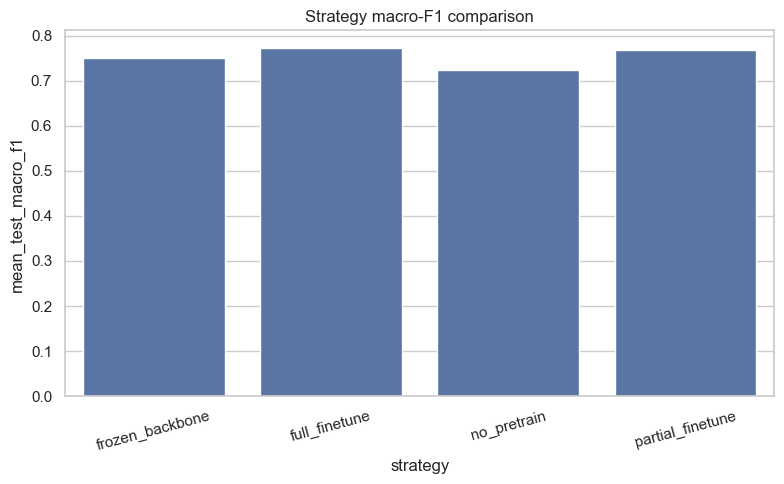

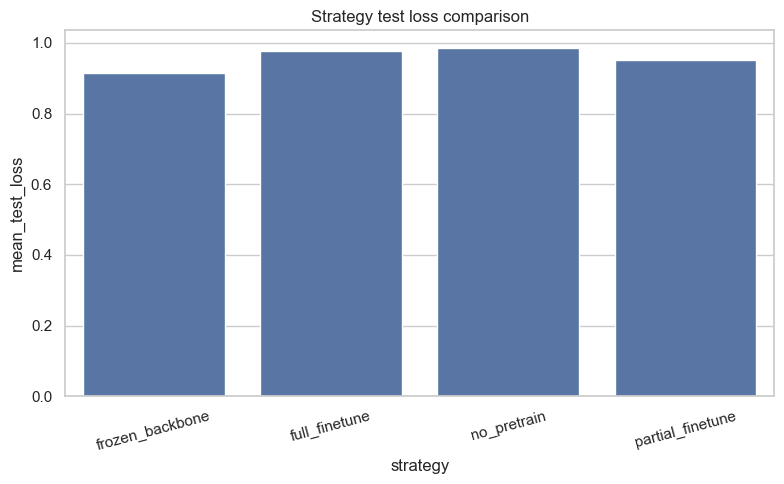

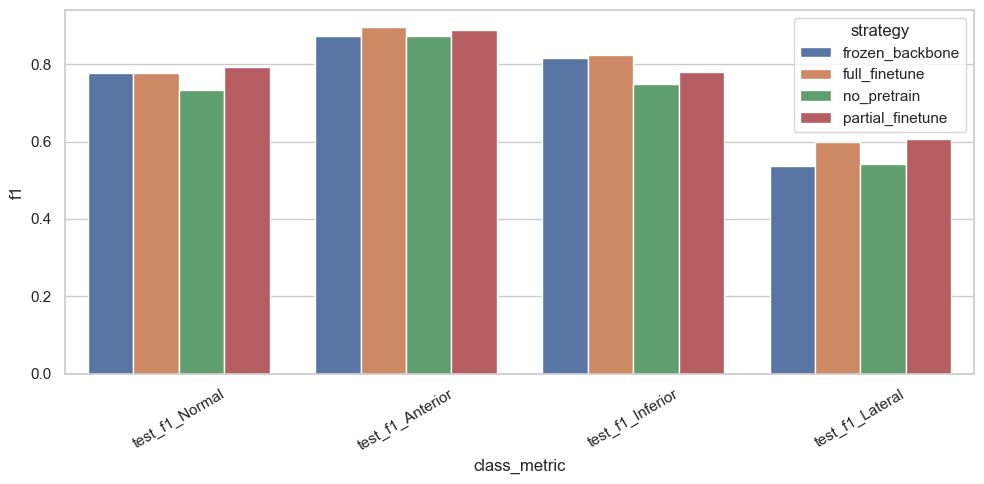

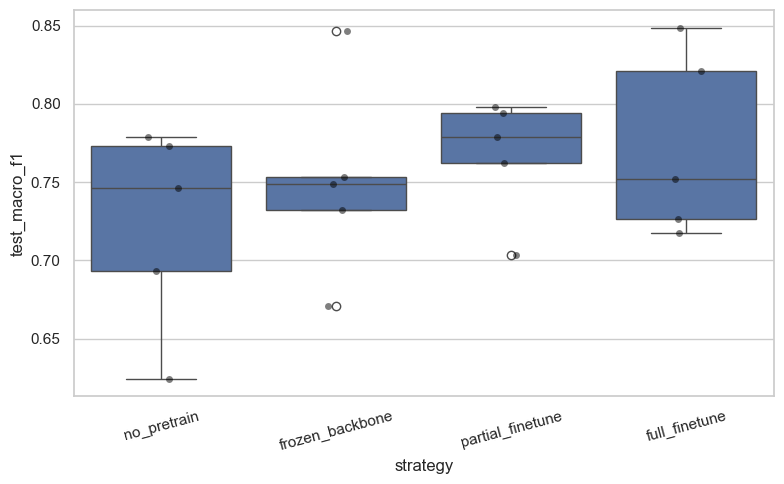

In [16]:
if len(ok):
    plt.figure(figsize=(8,5)); sns.barplot(data=avg,x='strategy',y='mean_test_macro_f1'); plt.xticks(rotation=15); plt.title('Strategy macro-F1 comparison'); plt.tight_layout(); plt.savefig(PLOTS_DIR/'strategy_macro_f1_comparison.png',dpi=250,bbox_inches='tight'); plt.show()
    plt.figure(figsize=(8,5)); sns.barplot(data=avg,x='strategy',y='mean_test_loss'); plt.xticks(rotation=15); plt.title('Strategy test loss comparison'); plt.tight_layout(); plt.savefig(PLOTS_DIR/'strategy_val_loss_comparison.png',dpi=250,bbox_inches='tight'); plt.show()
    f1_df=pd.read_csv(AGG_DIR/'per_class_f1_by_strategy.csv').melt(id_vars='strategy', var_name='class_metric', value_name='f1'); plt.figure(figsize=(10,5)); sns.barplot(data=f1_df,x='class_metric',y='f1',hue='strategy'); plt.xticks(rotation=30); plt.tight_layout(); plt.savefig(PLOTS_DIR/'per_class_f1_comparison.png',dpi=250,bbox_inches='tight'); plt.show()
    plt.figure(figsize=(8,5)); sns.boxplot(data=ok,x='strategy',y='test_macro_f1'); sns.stripplot(data=ok,x='strategy',y='test_macro_f1',color='black',alpha=.5); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig(PLOTS_DIR/'foldwise_macro_f1_boxplot.png',dpi=250,bbox_inches='tight'); plt.show()

## 17. Best model selection

In [17]:
print('Best model summary:')
display(best)
with open(LOG_DIR / 'run_summary.txt', 'w') as f:
    f.write('ALPA-Net PTB Diagnostic transfer CV summary\n')
    f.write(f'Output: {OUTPUT_DIR}\n')
    f.write(f'Pretrain: {PRETRAIN_SOURCE.get("run_dir")}\n')
    f.write(json.dumps(best, indent=2))

Best model summary:


{'fold': 1,
 'strategy': 'full_finetune',
 'status': 'OK',
 'error': nan,
 'val_macro_f1': 0.7640350509412603,
 'test_macro_f1': 0.8487370610610047,
 'test_loss': 0.6339688264252095,
 'test_micro_f1': 0.8308823529411765,
 'test_weighted_f1': 0.8481162510551442,
 'test_auroc_macro': 0.957371711730957,
 'test_auprc_macro': 0.9423162937164308,
 'test_hamming_loss': 0.1292134831460674,
 'test_subset_accuracy': 0.5617977528089888,
 'test_precision_Normal': 0.8421052631578947,
 'test_recall_Normal': 1.0,
 'test_f1_Normal': 0.9142857142857144,
 'test_auroc_Normal': 1.0,
 'test_auprc_Normal': 1.0,
 'test_precision_Anterior': 0.9696969696969696,
 'test_recall_Anterior': 0.8421052631578947,
 'test_f1_Anterior': 0.9014084507042254,
 'test_auroc_Anterior': 0.9809081554412842,
 'test_auprc_Anterior': 0.9806626439094543,
 'test_precision_Inferior': 0.9722222222222222,
 'test_recall_Inferior': 0.8333333333333334,
 'test_f1_Inferior': 0.8974358974358975,
 'test_auroc_Inferior': 0.978723406791687,
 'te

## 18. Transfer learning diagnostic summary

In [18]:
summary = {
    'pretrain_source': PRETRAIN_SOURCE,
    'strategies': CONFIG['STRATEGIES'],
    'n_folds': CONFIG['N_FOLDS'],
    'label_mapping': LABEL_MAPPING,
    'lead_prior_config': LEAD_PRIOR_CONFIG,
    'outputs': str(OUTPUT_DIR),
    'failed_runs': all_fold_metrics[~all_fold_metrics['status'].eq('OK')].to_dict(orient='records') if 'all_fold_metrics' in globals() else [],
}
with open(AGG_DIR / 'transfer_diagnostic_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
display(summary)
print('Done:', OUTPUT_DIR)

{'pretrain_source': {'run_dir': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207',
  'transfer_dir': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207/transfer_ready',
  'checkpoint_source': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207/checkpoints/best_macro_f1.pt',
  'backbone': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207/transfer_ready/alpanet_backbone.pt',
  'full_model': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207/transfer_ready/alpanet_full_model.pt',
  'model_config': '/home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_1902

Done: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/finetune_alpanet_ptbdiagnostic/20260607_200953
